In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmcrameri import cm

# Draft results for Iran project

load ERA5 and AIFS datasets
select for time of the event

Project is about record dew points in Iran 31-07-2025 UTC6:00
2 meter dewpoint
t for temp
q for specific humidity at 1000, 700 and 500 hPa.

## Load ERA 5 dataset xarray

In [2]:
#pl comtains temp and specific humidity t and q
ds_ERA5_pl=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar in Climatology/Iran_data/ERA5_05_DewPoints_Iran_pl_2025-07-31_06UTC.nc')

ds_ERA5_pl


<xarray.Dataset> Size: 1MB
Dimensions:        (isobaricInhPa: 10, latitude: 81, longitude: 161)
Coordinates:
  * isobaricInhPa  (isobaricInhPa) float64 80B 1e+03 925.0 900.0 ... 300.0 250.0
  * latitude       (latitude) float64 648B 35.0 34.75 34.5 ... 15.5 15.25 15.0
  * longitude      (longitude) float64 1kB 35.0 35.25 35.5 ... 74.5 74.75 75.0
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
    valid_time     datetime64[ns] 8B ...
Data variables:
    q              (isobaricInhPa, latitude, longitude) float32 522kB ...
    t              (isobaricInhPa, latitude, longitude) float32 522kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
#sfc file contains dew point two meter

ds_ERA5_sfc=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar in Climatology/Iran_data/ERA5_05_DewPoints_Iran_sfc_2025-07-31_06UTC.nc')

ds_ERA5_sfc

<xarray.Dataset> Size: 54kB
Dimensions:     (latitude: 81, longitude: 161)
Coordinates:
  * latitude    (latitude) float64 648B 35.0 34.75 34.5 ... 15.5 15.25 15.0
  * longitude   (longitude) float64 1kB 35.0 35.25 35.5 ... 74.5 74.75 75.0
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    d2m         (latitude, longitude) float32 52kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

## Load AIFS data

In [4]:
ds_AIFS_pl=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar in Climatology/Iran_data/AIFS-ENS_05_DewPoints_Iran_pl_2025-07-31_06UTC.nc')

ds_AIFS_pl

<xarray.Dataset> Size: 156MB
Dimensions:        (ensemble_members: 50, leadtime: 10, isobaricInhPa: 3,
                    latitude: 81, longitude: 161)
Coordinates:
    number         (ensemble_members) int64 400B ...
  * leadtime       (leadtime) int64 80B 1 2 3 4 5 6 7 8 9 10
    fc_init_time   (leadtime) datetime64[ns] 80B ...
    fc_valid_time  (leadtime) datetime64[ns] 80B ...
  * isobaricInhPa  (isobaricInhPa) float64 24B 1e+03 700.0 500.0
  * latitude       (latitude) float64 648B 35.0 34.75 34.5 ... 15.5 15.25 15.0
  * longitude      (longitude) float64 1kB 35.0 35.25 35.5 ... 74.5 74.75 75.0
Dimensions without coordinates: ensemble_members
Data variables:
    t              (ensemble_members, leadtime, isobaricInhPa, latitude, longitude) float32 78MB ...
    q              (ensemble_members, leadtime, isobaricInhPa, latitude, longitude) float32 78MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T13:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
#load aifs sfc
ds_AIFS_sfc=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar in Climatology/Iran_data/AIFS-ENS_05_DewPoints_Iran_sfc_2025-07-31_06UTC.nc')

ds_AIFS_sfc

<xarray.Dataset> Size: 26MB
Dimensions:            (ensemble_members: 50, leadtime: 10, latitude: 81,
                        longitude: 161)
Coordinates:
    number             (ensemble_members) int64 400B ...
  * leadtime           (leadtime) int64 80B 1 2 3 4 5 6 7 8 9 10
    fc_init_time       (leadtime) datetime64[ns] 80B ...
    fc_valid_time      (leadtime) datetime64[ns] 80B ...
  * latitude           (latitude) float64 648B 35.0 34.75 34.5 ... 15.25 15.0
  * longitude          (longitude) float64 1kB 35.0 35.25 35.5 ... 74.75 75.0
    heightAboveGround  float64 8B ...
Dimensions without coordinates: ensemble_members
Data variables:
    d2m                (ensemble_members, leadtime, latitude, longitude) float32 26MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T11:08 GRIB to CDM+CF via cfgrib-0.9.1...

## Select target timestep for all files

In [6]:
# def seltime (dataset):
#     dataset.sel(valid_time='2025-07-31T06:00:00')

In [7]:
#ds_AIFS_sfc=ds_AIFS_sfc.sel(valid_time='2025-07-31T06:00:00')
#ds_AIFS_pl=ds_ERA5_pl.sel(valid_time='2025-07-31T06:00:00')
#ds_ERA5_sfc=ds_ERA5_sfc.sel(valid_time='2025-07-31T06:00:00')
#ds_ERA5_pl=ds_ERA5_pl.sel(valid_time='2025-07-31T06:00:00')

There is no valid-time datapoint

## select for lat lon the area

In [8]:
#alredy defined

ds_AIFS_sfc.longitude



<xarray.DataArray 'longitude' (longitude: 161)> Size: 1kB
array([35.  , 35.25, 35.5 , 35.75, 36.  , 36.25, 36.5 , 36.75, 37.  , 37.25,
       37.5 , 37.75, 38.  , 38.25, 38.5 , 38.75, 39.  , 39.25, 39.5 , 39.75,
       40.  , 40.25, 40.5 , 40.75, 41.  , 41.25, 41.5 , 41.75, 42.  , 42.25,
       42.5 , 42.75, 43.  , 43.25, 43.5 , 43.75, 44.  , 44.25, 44.5 , 44.75,
       45.  , 45.25, 45.5 , 45.75, 46.  , 46.25, 46.5 , 46.75, 47.  , 47.25,
       47.5 , 47.75, 48.  , 48.25, 48.5 , 48.75, 49.  , 49.25, 49.5 , 49.75,
       50.  , 50.25, 50.5 , 50.75, 51.  , 51.25, 51.5 , 51.75, 52.  , 52.25,
       52.5 , 52.75, 53.  , 53.25, 53.5 , 53.75, 54.  , 54.25, 54.5 , 54.75,
       55.  , 55.25, 55.5 , 55.75, 56.  , 56.25, 56.5 , 56.75, 57.  , 57.25,
       57.5 , 57.75, 58.  , 58.25, 58.5 , 58.75, 59.  , 59.25, 59.5 , 59.75,
       60.  , 60.25, 60.5 , 60.75, 61.  , 61.25, 61.5 , 61.75, 62.  , 62.25,
       62.5 , 62.75, 63.  , 63.25, 63.5 , 63.75, 64.  , 64.25, 64.5 , 64.75,
       65.  , 65.25, 65.5 , 65.75, 66.  , 66.25, 66.5 , 66.75, 67.  , 67.25,
       67.5 , 67.75, 68.  , 68.25, 68.5 , 68.75, 69.  , 69.25, 69.5 , 69.75,
       70.  , 70.25, 70.5 , 70.75, 71.  , 71.25, 71.5 , 71.75, 72.  , 72.25,
       72.5 , 72.75, 73.  , 73.25, 73.5 , 73.75, 74.  , 74.25, 74.5 , 74.75,
       75.  ])
Coordinates:
  * longitude          (longitude) float64 1kB 35.0 35.25 35.5 ... 74.75 75.0
    heightAboveGround  float64 8B ...
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude

## Transform from kelvin to °c

In [15]:
ds_AIFS_sfc=ds_AIFS_sfc.assign(d2m_C=lambda ds_AIFS_sfc: (ds_AIFS_sfc.d2m-273.15))

ds_AIFS_sfc.d2m_C

ds_AIFS_pl=ds_AIFS_pl.assign(t_C=lambda ds_AIFS_pl: (ds_AIFS_pl.t-273.15))

ds_AIFS_pl.t_C

ds_ERA5_pl=ds_ERA5_pl.assign(t_C=lambda ds_ERA5_pl: (ds_ERA5_pl.t-273.15))

ds_ERA5_pl.t_C

ds_ERA5_sfc=ds_ERA5_sfc.assign(d2m_C=lambda ds_ERA5_sfc: (ds_ERA5_sfc.d2m-273.15))

ds_ERA5_sfc.d2m_C

<xarray.DataArray 'd2m_C' (latitude: 81, longitude: 161)> Size: 52kB
array([[22.840729 , 22.30362  , 21.842682 , ...,  7.5887756,  6.9032288,
         7.4149475],
       [22.004791 , 21.674713 , 21.967682 , ..., 12.246979 , 10.452057 ,
         9.8368225],
       [21.39737  , 21.506744 , 21.5419   , ..., 16.543854 , 14.803619 ,
         9.537994 ],
       ...,
       [18.313385 , 18.311432 , 18.278229 , ..., 22.237213 , 21.852448 ,
        21.73526  ],
       [18.51065  , 18.528229 , 18.590729 , ..., 22.32315  , 22.098541 ,
        22.102448 ],
       [18.651276 , 18.705963 , 18.799713 , ..., 22.387604 , 22.202057 ,
        22.143463 ]], shape=(81, 161), dtype=float32)
Coordinates:
  * latitude    (latitude) float64 648B 35.0 34.75 34.5 ... 15.5 15.25 15.0
  * longitude   (longitude) float64 1kB 35.0 35.25 35.5 ... 74.5 74.75 75.0
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             168
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      13041
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2d
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown

## plot 2 m dewpoint

In [18]:
AIFS_d2m=ds_AIFS_sfc.d2m_C

AIFS_d2m

<xarray.DataArray 'd2m_C' (ensemble_members: 50, leadtime: 10, latitude: 81,
                           longitude: 161)> Size: 26MB
array([[[[22.81189  , 22.982788 , 23.354858 , ...,  7.0872803,
           6.4261475,  6.9593506],
         [22.074585 , 22.698608 , 22.89392  , ..., 11.788452 ,
          10.702515 ,  9.924194 ],
         [21.435913 , 21.87146  , 22.225952 , ..., 16.744507 ,
          15.701538 ,  9.31189  ],
         ...,
         [17.727905 , 17.84607  , 17.798218 , ..., 22.828491 ,
          22.756226 , 23.091187 ],
         [18.769897 , 19.026733 , 19.223022 , ..., 24.335327 ,
          24.253296 , 23.629272 ],
         [19.310913 , 19.669312 , 20.06482  , ..., 24.799194 ,
          24.440796 , 23.664429 ]],

        [[23.248047 , 22.999023 , 22.999023 , ...,  5.2626953,
           4.1591797,  3.5771484],
         [23.09668  , 23.264648 , 23.225586 , ..., 10.358398 ,
           8.316406 ,  5.7978516],
         [22.831055 , 23.03711  , 23.029297 , ..., 16.786133 ,
          14.738281 ,  6.694336 ],
...
          22.027832 , 21.503418 ],
         [18.952637 , 19.675293 , 20.007324 , ..., 23.478027 ,
          22.39209  , 21.342285 ],
         [19.187012 , 19.757324 , 19.918457 , ..., 23.997559 ,
          21.92627  , 20.973145 ]],

        [[24.685852 , 24.440735 , 23.942688 , ...,  6.5198364,
           6.369446 ,  6.462219 ],
         [23.718079 , 23.80597  , 23.14386  , ..., 12.049133 ,
          10.480774 ,  9.120422 ],
         [23.249329 , 22.14386  , 21.817688 , ..., 15.917297 ,
          14.286438 ,  9.39093  ],
         ...,
         [19.92511  , 19.929993 , 20.08136  , ..., 22.113586 ,
          21.505188 , 21.782532 ],
         [20.49347  , 20.512024 , 20.221985 , ..., 23.333313 ,
          22.387024 , 21.840149 ],
         [20.432922 , 20.557922 , 20.158508 , ..., 23.652649 ,
          22.80304  , 21.877258 ]]]],
      shape=(50, 10, 81, 161), dtype=float32)
Coordinates:
    number             (ensemble_members) int64 400B ...
  * leadtime           (leadtime) int64 80B 1 2 3 4 5 6 7 8 9 10
    fc_init_time       (leadtime) datetime64[ns] 80B ...
    fc_valid_time      (leadtime) datetime64[ns] 80B ...
  * latitude           (latitude) float64 648B 35.0 34.75 34.5 ... 15.25 15.0
  * longitude          (longitude) float64 1kB 35.0 35.25 35.5 ... 74.75 75.0
    heightAboveGround  float64 8B ...
Dimensions without coordinates: ensemble_members
Attributes: (12/31)
    GRIB_paramId:                             168
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      13041
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2d
    GRIB_totalNumber:                         51
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown

In [29]:
print(ds_AIFS_sfc.d2m_C.max())

<xarray.DataArray 'd2m_C' ()> Size: 4B
array(34.708588, dtype=float32)
Coordinates:
    heightAboveGround  float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             168
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      13041
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2d
    GRIB_totalNumber:                         51
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown


/var/folders/wf/ksd_n1r53pg13t3sw9dpy5580000gn/T/ipykernel_68216/140532519.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


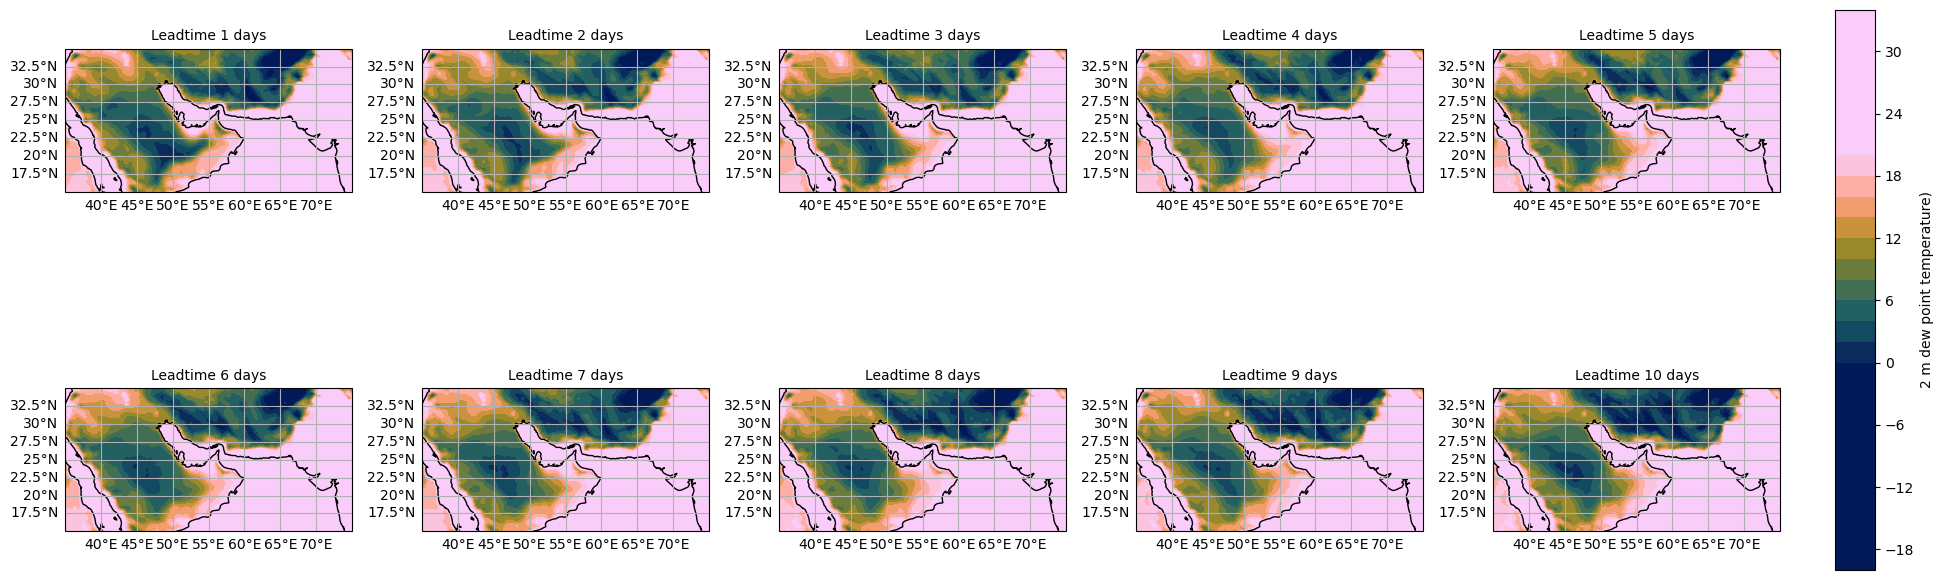

In [26]:
# Ensemble mean
ens_mean = ds_AIFS_sfc.mean(dim="ensemble_members")

# Map projection
map_projection = ccrs.PlateCarree()

# Color levels
V_levels = np.arange(-20, 35, 2)

# Create 2x5 subplot grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8),
                         subplot_kw={'projection': map_projection})
axes = axes.flatten()

for i, lt in enumerate(ens_mean.leadtime.values):
    ax = axes[i]
    
    # Select leadtime
    ds_sel = ens_mean.sel(leadtime=lt)
    
    # Plot wind speed (matplotlib contourf)
    cf = ax.contourf(
        ds_sel.longitude,
        ds_sel.latitude,
        ds_sel['d2m_C'],
        levels=V_levels,
        cmap=cm.batlow,
        vmin=0,
        vmax=20,
        transform=map_projection
    )
    
    
    # Add coastlines
    ax.add_feature(cfeature.COASTLINE, linestyle='-')
    
    # Add subplot title
    ax.set_title(f'Leadtime {lt} days', fontsize=10)

    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# Add single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cf, cax=cbar_ax, label=r'2 m dew point temperature)')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar

